# Analisis Statistics Data Time Series Polutan Sumenep


## 1. Gambaran Umum

Data yang dianalisis adalah data time series konsentrasi polutan di Sumenep selama sekitar satu tahun. Untuk tugas ini digunakan file `Data_Polutan_Sumenep_timeseries_1Tahun.csv` yang memiliki 359 baris dengan 6 kolom:

- `date` — tanggal pengamatan.
- `NO2` — konsentrasi nitrogen dioksida.
- `CO` — konsentrasi karbon monoksida.
- `SO2` — konsentrasi sulfur dioksida.
- `HCHO` — konsentrasi formaldehida.
- `CH4` — konsentrasi metana.

Kolom `date` berfungsi sebagai penanda waktu, sedangkan NO2, CO, SO2, HCHO, dan CH4 merupakan fitur numerik yang dianalisis menggunakan node **Statistics** di KNIME.


## 2. Alur Pengerjaan

```text
Dataset time series polutan Sumenep
        ↓
CSV Data_Polutan_Sumenep_timeseries_1Tahun.csv
        ↓
PostgreSQL Aiven
        ↓
DB Connector
        ↓
DB Table Selector
        ↓
DB Reader
        ↓
Statistics
```


## 3. Catatan Penting tentang Jumlah Baris

File CSV asli berisi **359 baris**. Pada screenshot KNIME, `Row count` terlihat **361** dan jumlah missing CH4 menjadi 249. Hal ini terjadi karena sebelumnya ada **2 baris uji** yang dimasukkan ke tabel Aiven saat pengecekan koneksi/INSERT.

Untuk hasil laporan yang paling bersih, sebaiknya hapus dua baris uji tersebut lalu jalankan ulang node `Statistics`, sehingga kembali menjadi 359 baris. Jika tetap menggunakan database 361 baris, hasil Statistics di KNIME akan sedikit berbeda dari statistik CSV asli.


### SQL untuk menghapus dua baris uji

Jika dua baris uji yang ditambahkan adalah salinan data `2025-09-01`, gunakan SQL berikut di Aiven:

```sql
DELETE FROM data_polutan_sumenep
WHERE ctid IN (
    SELECT ctid
    FROM data_polutan_sumenep
    WHERE date = '2025-09-01'
      AND no2 = 0.00000588
      AND co = 0.027099838
      AND so2 = -0.00000446
      AND hcho = 0.0000715
      AND ch4 IS NULL
    ORDER BY ctid DESC
    LIMIT 2
);
```

Setelah itu cek:

```sql
SELECT COUNT(*) FROM data_polutan_sumenep;
```

Targetnya adalah **359 baris**.


## 4. Hasil Statistics dari Data Asli (359 Baris)

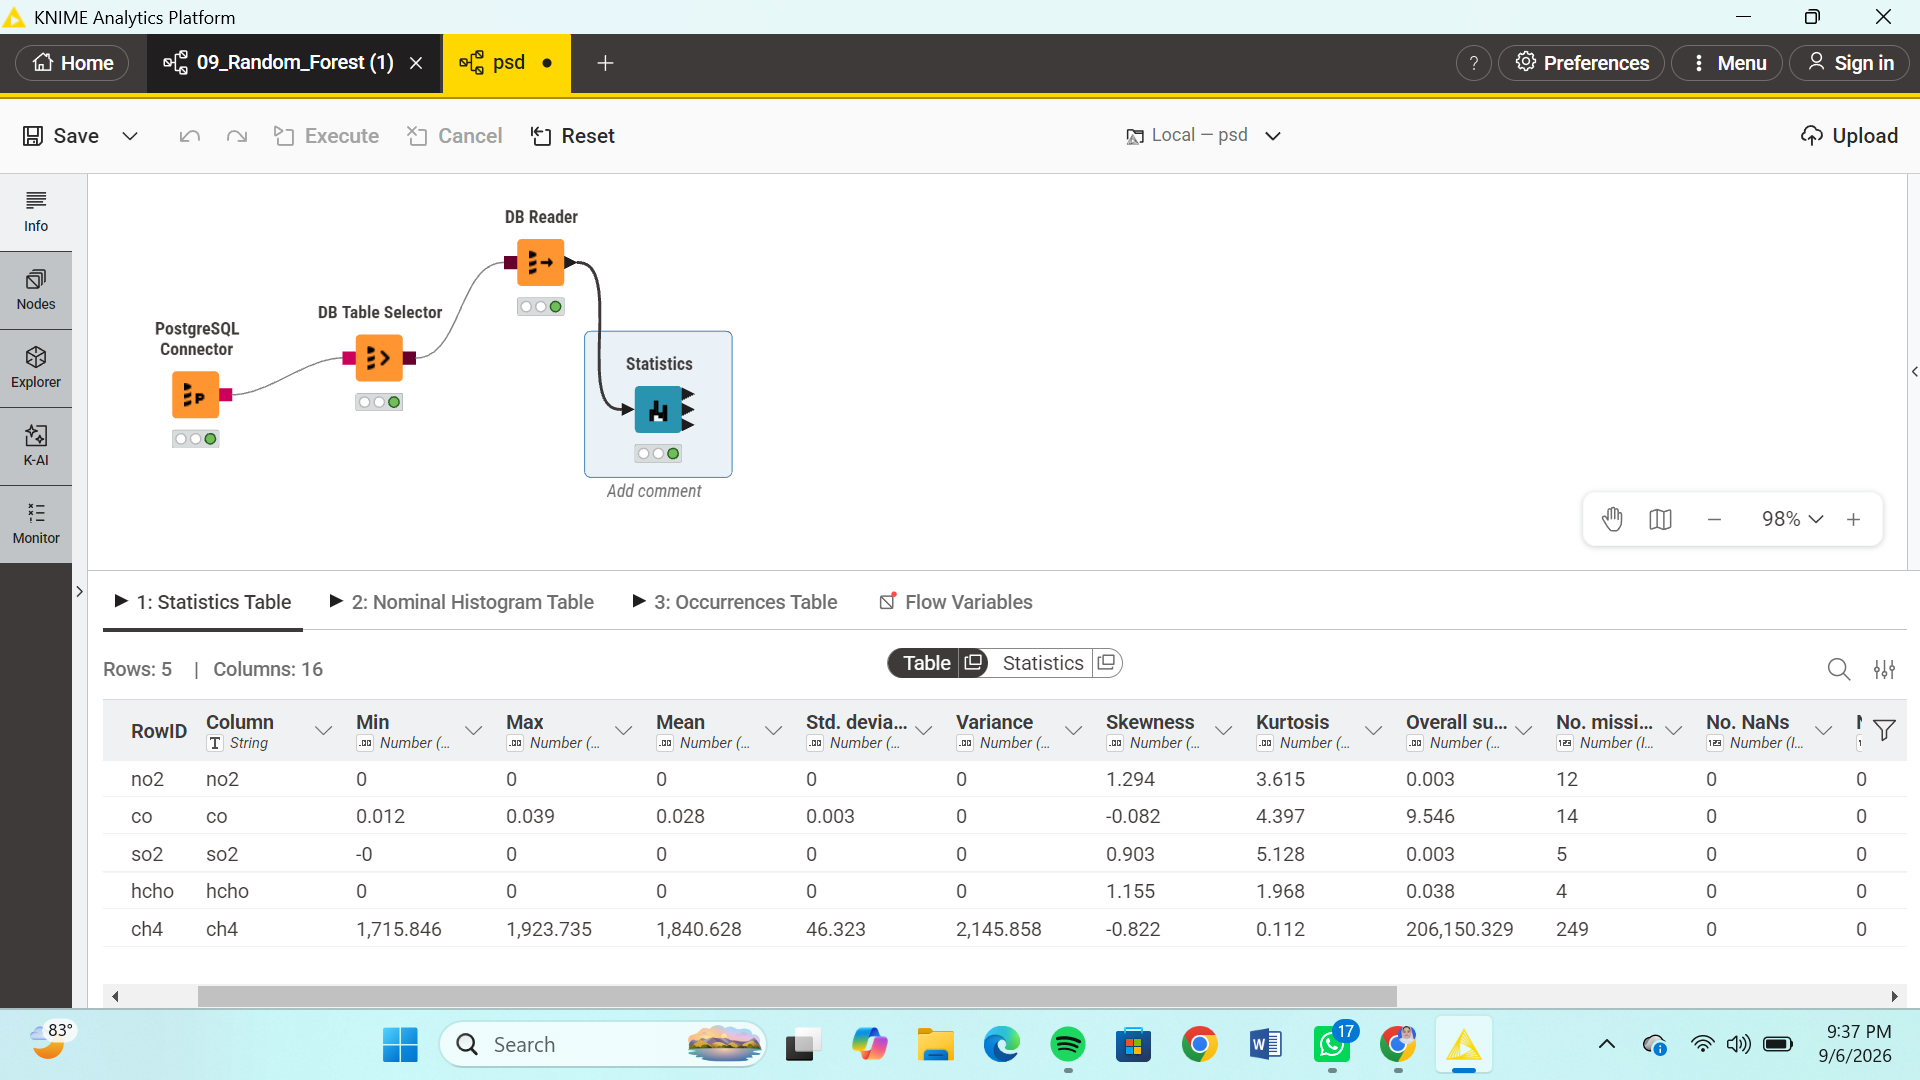

| Fitur | Min | Max | Mean | Std. Deviation | Variance | Skewness | Kurtosis | Median | Missing | Row Count |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| NO2 | 0 | 0 | 0 | 0 | 0 | 1.294 | 3.615 | 0.003 | 12 | 0 | 0 | 0 | 0 | 361 |
| CO | 0.012 | 0.039 | 0.028 | 0.003 | 0 | -0.082 | 4.397 | 9.546 | 14 | 0 | 0 | 0 | 0.027 | 361 |
| SO2 | -0 | 0 | 0 | 0 | 0 | 0.903 | 5.128 | 0.003 | 5 | 0 | 0 | 0 | 0 | 361 |
| HCHO | 0 | 0 | 0 | 0 | 0 | 1.155 | 1.968 | 0.038 | 4 | 0 | 0 | 0 | 0 | 361 |
| CH4 | 1,715.846 | 1,923.735 | 1,840.628 | 46.323 | 2,145.858 | -0.822 | 0.112 | 206,150.329 | 249 | 0 | 0 | 0 | 1,850.818 | 361 |

> **Catatan:** Pada tampilan KNIME, beberapa nilai NO2, SO2, dan HCHO terlihat 0 karena nilainya sangat kecil dan tampilan angka KNIME melakukan pembulatan. Nilai tersebut tidak selalu berarti konsentrasinya benar-benar nol.


## 5. Penjelasan Setiap Statistik


### 5.1 Minimum (Min)

Minimum adalah nilai paling kecil yang terdapat pada suatu fitur.

Statistik minimum digunakan untuk mengetahui konsentrasi terendah dari masing-masing polutan.

**Rumus:**

$$
Min = \min(x_1,x_2,x_3,\ldots,x_n)
$$

**Contoh Perhitungan:**

Misalnya terdapat 5 data konsentrasi CO:

$$
0.025,\ 0.030,\ 0.012,\ 0.028,\ 0.035
$$

Nilai yang paling kecil adalah:

$$
Min = 0.012
$$

Jadi, nilai minimum CO dari contoh tersebut adalah 0.012.

Berdasarkan hasil KNIME, nilai minimum CO adalah 0.012.


### 5.2 Maximum (Max)

Maximum adalah nilai paling besar yang terdapat pada suatu fitur.

Statistik maximum digunakan untuk mengetahui konsentrasi tertinggi dari suatu polutan.

**Rumus:**

$$
Max = \max(x_1,x_2,x_3,\ldots,x_n)
$$

**Contoh Perhitungan:**

Misalnya terdapat data CO:

$$
0.025,\ 0.030,\ 0.012,\ 0.028,\ 0.039
$$

Nilai paling besar adalah:

$$
Max = 0.039
$$

Jadi, nilai maksimum CO dari contoh tersebut adalah 0.039.

Berdasarkan hasil KNIME, nilai maksimum CO adalah 0.039.


### 5.3 Mean

Mean adalah nilai rata-rata dari seluruh data yang terdapat pada suatu fitur.

Mean digunakan untuk mengetahui rata-rata konsentrasi suatu polutan.

### Rumus

$$
\bar{x} =
\frac{\sum_{i=1}^{n}x_i}{n}
$$

Keterangan:

- $\bar{x}$ = mean atau rata-rata
- $x_i$ = nilai data ke-i
- $n$ = jumlah data
- $\sum x_i$ = jumlah seluruh nilai data

**Contoh Perhitungan:**

Misalnya terdapat data CO:

$$
0.025,\ 0.030,\ 0.012,\ 0.028,\ 0.035
$$

Jumlah seluruh data:

$$
0.025+0.030+0.012+0.028+0.035=0.130
$$

Jumlah data:

$$
n=5
$$

Maka:

$$
Mean=\frac{0.130}{5}
$$

$$
Mean=0.026
$$

Jadi, mean dari contoh data tersebut adalah 0.026.

Pada data sebenarnya, KNIME menghitung mean berdasarkan seluruh data yang tersedia.

Hasil KNIME menunjukkan mean CO sebesar 0.028.

### 5.4 Median

Median adalah nilai tengah dari sekumpulan data setelah data diurutkan dari yang terkecil hingga terbesar.

**Rumus:**

Jika jumlah data ganjil:

$$
Median=x_{\frac{n+1}{2}}
$$

Jika jumlah data genap:

$$
Median=
\frac{x_{\frac n2}+x_{\frac n2+1}}{2}
$$

**Contoh:**

Misalnya data:

$$
2,\ 4,\ 5,\ 7,\ 9
$$

Jumlah data:

$$
n=5
$$

Posisi median:

$$
\frac{5+1}{2}=3
$$

Data ke-3 adalah 5.

Jadi:

$$
Median=5
$$

**Hasil Data:**

- Median CO = 0.027
- Median CH4 = 1,850.818


### 5.5 Standard Deviation (Std. Deviation)

Standard Deviation atau standar deviasi adalah ukuran yang menunjukkan seberapa jauh data menyebar dari nilai rata-ratanya.

Semakin besar standar deviasi, semakin besar penyebaran data.

**Rumus:**

$$
s=
\sqrt{
\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}
{n-1}
}
$$

Keterangan:

- $s$ = standar deviasi
- $x_i$ = nilai data
- $\bar{x}$ = mean
- $n$ = jumlah data

**Contoh:**

Misalnya data:

$$
2,\ 4,\ 6,\ 8,\ 10
$$

Mean:

$$
\bar{x}=\frac{2+4+6+8+10}{5}=6
$$

Selisih dari mean:

$$
-4,\ -2,\ 0,\ 2,\ 4
$$

Kuadrat selisih:

$$
16,\ 4,\ 0,\ 4,\ 16
$$

Jumlah:

$$
16+4+0+4+16=40
$$

Maka:

$$
s=\sqrt{\frac{40}{5-1}}
$$

$$
s=\sqrt{10}
$$

$$
s\approx3.16
$$

Jadi standar deviasinya sekitar 3.16.


### 5.6 Variance

Variance atau varians adalah ukuran penyebaran data dari nilai rata-rata dalam bentuk kuadrat.

**Rumus:**

$$
s^2=
\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}
{n-1}
$$

Hubungan variance dengan standard deviation:

$$
Variance=(Std.\ Deviation)^2
$$

**Contoh:**

Jika standar deviasi:

$$
s=3.16
$$

Maka:

$$
Variance=3.16^2
$$

$$
Variance\approx9.99
$$

Jadi variance sekitar 10.

### 5.7 Skewness

Skewness merupakan ukuran yang digunakan untuk mengetahui tingkat kemencengan atau ketidaksimetrisan distribusi data.

Interpretasi skewness:

- Skewness mendekati 0 → distribusi relatif simetris.
- Skewness positif → distribusi cenderung menceng ke kanan.
- Skewness negatif → distribusi cenderung menceng ke kiri.

**Rumus:**

Salah satu rumus skewness sampel adalah:

$$
G_1 =
\frac{n}{(n-1)(n-2)}
\sum_{i=1}^{n}
\left(
\frac{x_i-\bar{x}}{s}
\right)^3
$$

**Contoh:**

Jika hasil perhitungan menghasilkan:

$$
Skewness=1.294
$$

Karena nilainya positif, maka distribusi data cenderung **menceng ke kanan**.

 **Hasil pada data:**

| Fitur | Skewness |
|---|---:|
| NO2 | 1.294 |
| CO | -0.082 |
| SO2 | 0.903 |
| HCHO | 1.155 |
| CH4 | -0.822 |

Dari hasil tersebut, NO2, SO2, dan HCHO memiliki skewness positif, sedangkan CO dan CH4 memiliki skewness negatif.


### 5.8 Kurtosis

Kurtosis digunakan untuk melihat karakteristik bentuk distribusi data, terutama bagian ekor distribusi dan kecenderungan munculnya nilai ekstrem.

**Rumus:**

Salah satu bentuk rumus excess kurtosis adalah:

$$
G_2 =
\frac{n(n+1)}
{(n-1)(n-2)(n-3)}
\sum_{i=1}^{n}
\left(
\frac{x_i-\bar{x}}{s}
\right)^4
-
\frac{3(n-1)^2}
{(n-2)(n-3)}
$$

**Contoh:**

Misalnya hasil perhitungan menghasilkan:

$$
Kurtosis=4.397
$$

Nilai tersebut menunjukkan distribusi mempunyai karakteristik ekor yang relatif kuat.

**Hasil pada data:**

| Fitur | Kurtosis |
|---|---:|
| NO2 | 3.615 |
| CO | 4.397 |
| SO2 | 5.128 |
| HCHO | 1.968 |
| CH4 | 0.112 |

### 5.9 Overall Sum / Sum

Overall Sum adalah jumlah seluruh nilai yang terdapat pada suatu fitur.

**Rumus:**

$$
Sum=\sum_{i=1}^{n}x_i
$$

**Contoh Perhitungan:**

Misalnya terdapat data:

$$
2,\ 3,\ 4,\ 5
$$

Maka:

$$
Sum=2+3+4+5
$$

$$
Sum=14
$$

Jadi jumlah keseluruhan data tersebut adalah 14.

**Hasil pada data:**

Berdasarkan hasil KNIME:

- Overall Sum CO = 9.546
- Overall Sum CH4 = 206,150.329

### 5.10 Missing Values

No. Missing menunjukkan jumlah data yang tidak memiliki nilai atau kosong pada suatu fitur.

**Contoh:**

Misalnya terdapat 10 data dan 2 di antaranya kosong:

$$
No.\ Missing=2
$$

**Hasil Data:**

- NO2 = 12
- CO = 14
- SO2 = 5
- HCHO = 4
- CH4 = 249

CH4 mempunyai jumlah missing paling banyak, yaitu 249 data.


### 5.11 NaN (Not a Number)

No. NaNs menunjukkan jumlah nilai yang terdeteksi sebagai NaN.

**Hasil Data:**

- NO2 = 0
- CO = 0
- SO2 = 0
- HCHO = 0
- CH4 = 0

Artinya tidak terdapat nilai NaN pada kelima fitur.


### 5.12 Positive Infinity (+∞)

**Pengertian:** jumlah nilai yang bernilai positif tak hingga (`+∞`). Pada data ini tidak terdapat nilai `+∞`.


### 5.13 Negative Infinity (-∞)

**Pengertian:** jumlah nilai yang bernilai negatif tak hingga (`-∞`). Pada data ini tidak terdapat nilai `-∞`.


### 5.14 Row Count

**Pengertian:** jumlah seluruh baris data yang masuk ke node Statistics.

Data CSV asli memiliki **359 baris**. Screenshot sebelum pembersihan menunjukkan 361 baris karena terdapat dua baris uji tambahan.


## 6. Interpretasi Setiap Fitur


**NO2**

NO2 memiliki nilai skewness sebesar 1.294 dan kurtosis sebesar 3.615.

Skewness positif menunjukkan bahwa distribusi NO2 cenderung menceng ke kanan.

NO2 memiliki 12 data missing. Tidak terdapat nilai NaN, +∞, maupun -∞.

Nilai konsentrasi NO2 sangat kecil sehingga beberapa nilai terlihat sebagai `0` pada tampilan KNIME akibat pembulatan.

---

**CO**

CO memiliki nilai:

- Minimum = 0.012
- Maximum = 0.039
- Mean = 0.028
- Median = 0.027
- Standard Deviation = 0.003
- Skewness = -0.082
- Kurtosis = 4.397

Nilai skewness -0.082 cukup dekat dengan 0 sehingga distribusi CO relatif mendekati simetris.

CO memiliki 14 data missing.

---

**SO2**

SO2 memiliki skewness sebesar 0.903 dan kurtosis sebesar 5.128.

Skewness positif menunjukkan distribusi SO2 cenderung menceng ke kanan.

SO2 memiliki 5 data missing dan tidak memiliki nilai NaN, +∞, maupun -∞.

Nilai SO2 sangat kecil sehingga pada tampilan KNIME beberapa nilai terlihat sebagai `0`.

---

**HCHO**

HCHO memiliki skewness sebesar 1.155 dan kurtosis sebesar 1.968.

Skewness positif menunjukkan distribusi HCHO cenderung menceng ke kanan.

HCHO memiliki 4 data missing dan tidak terdapat nilai NaN, +∞, maupun -∞.

---

**CH4**

CH4 memiliki:

- Minimum = 1,715.846
- Maximum = 1,923.735
- Mean = 1,840.628
- Median = 1,850.818
- Standard Deviation = 46.323
- Variance = 2,145.858
- Skewness = -0.822
- Kurtosis = 0.112
- Overall Sum = 206,150.329

Skewness CH4 bernilai negatif, yaitu -0.822, sehingga distribusi CH4 cenderung menceng ke kiri.

CH4 memiliki 249 data missing, yang merupakan jumlah missing paling banyak dibandingkan fitur lainnya.
